In [2]:
!git clone https://github.com/madhurmd/hero-fincorp-loan-analysis.git

Cloning into 'hero-fincorp-loan-analysis'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 94 (delta 22), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 18.51 MiB | 8.24 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [3]:
%cd hero-fincorp-loan-analysis

/content/hero-fincorp-loan-analysis


# Task 1: Data Quality & Preparation

## Objective
Ensure datasets are clean, consistent, and analysis-ready by:
- Handling missing values
- Removing duplicates
- Standardizing formats
- Treating outliers

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))


def load_all_data(base_path="data/raw/"):
    customers = pd.read_csv(base_path + "customers.csv")
    loans = pd.read_csv(base_path + "loans.csv")
    applications = pd.read_csv(base_path + "applications.csv")
    transactions = pd.read_csv(base_path + "transactions.csv")
    defaults = pd.read_csv(base_path + "defaults.csv")
    branches = pd.read_csv(base_path + "branches.csv")

    return customers, loans, applications, transactions, defaults, branches

customers, loans, applications, transactions, defaults, branches = load_all_data()

/tmp/ipykernel_5982/1273596420.py:13: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(base_path + "applications.csv")


## Initial Data Overview
Understanding dataset shapes, columns, and basic structure.

In [7]:
datasets = {
    "Customers": customers,
    "Loans": loans,
    "Applications": applications,
    "Transactions": transactions,
    "Defaults": defaults,
    "Branches": branches
}

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print(f"Shape: {df.shape}")
    print("Columns:", df.columns.tolist())


Customers Dataset
----------------------------------------
Shape: (70000, 14)
Columns: ['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']

Loans Dataset
----------------------------------------
Shape: (90000, 12)
Columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']

Applications Dataset
----------------------------------------
Shape: (82600, 10)
Columns: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason']

Transactions Dataset
----------------------------------------
Shape: (495000, 9)
Columns: ['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction

## Missing Values Analysis
Identify columns with missing values to determine cleaning strategy.

In [8]:
for name, df in datasets.items():
    print(f"\n{name} Missing Values")
    print("-" * 40)
    print(df.isnull().sum().sort_values(ascending=False))


Customers Missing Values
----------------------------------------
Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

Loans Missing Values
----------------------------------------
Collateral_Details      30194
Loan_ID                     0
Loan_Amount                 0
Customer_ID                 0
Interest_Rate               0
Loan_Term                   0
Repayment_Start_Date        0
Disbursal_Date              0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
dtype: int64

Applications Missing Values
----------------------------------------
Rejectio

## Duplicate Records Check
Ensure no duplicate entries exist in datasets.

In [10]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Customers: 0 duplicate rows
Loans: 0 duplicate rows
Applications: 0 duplicate rows
Transactions: 0 duplicate rows
Defaults: 0 duplicate rows
Branches: 0 duplicate rows


## Date Format Standardization
Convert date columns into datetime format for consistency.

In [11]:
# Customers
# (No major date columns typically)

# Loans
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')

# Applications
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

# Transactions
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

# Defaults
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

## Outlier Detection
Identify extreme values in key numerical columns.

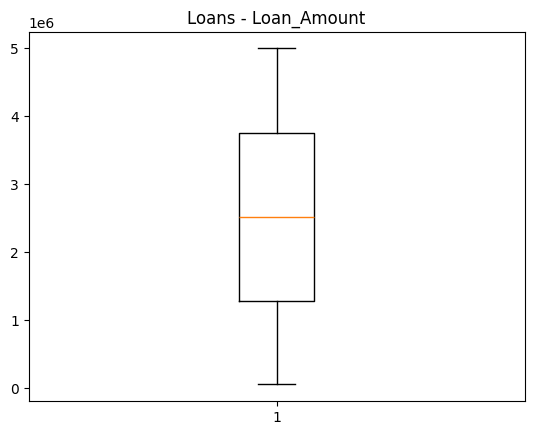

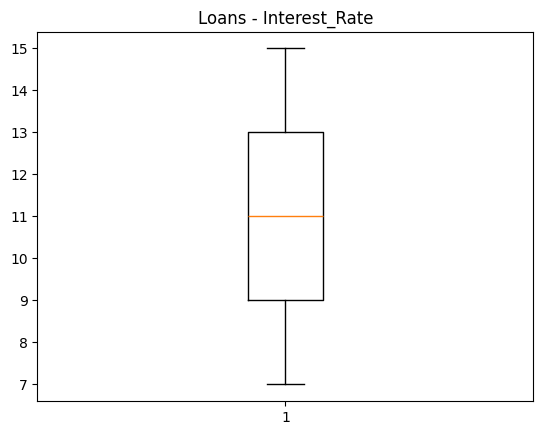

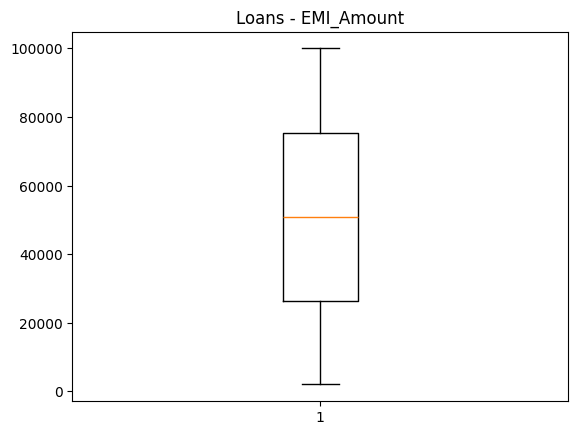

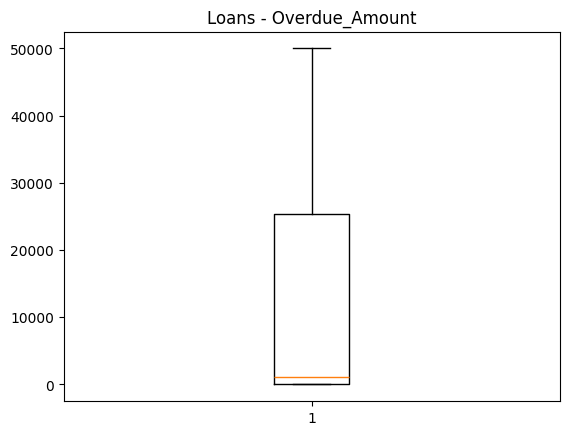

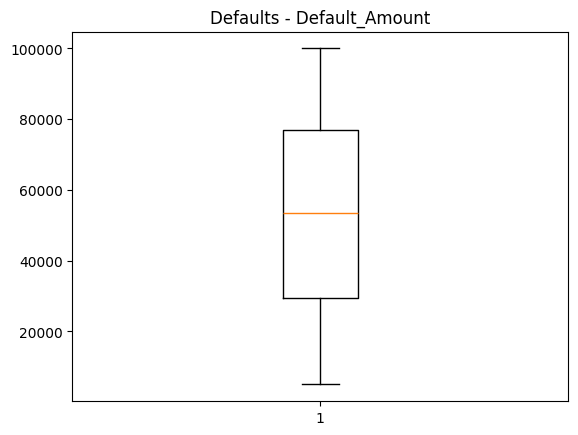

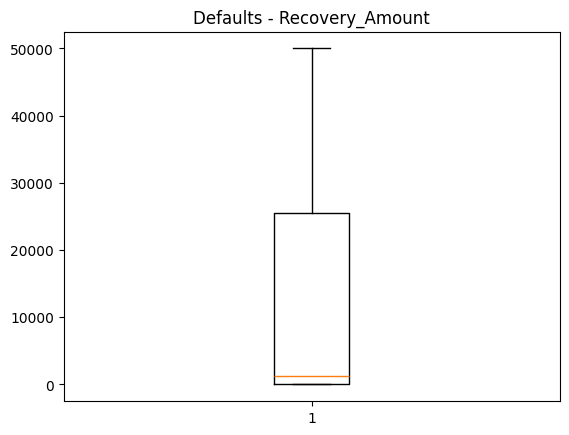

In [12]:
numeric_cols = {
    "Loans": ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"],
    "Defaults": ["Default_Amount", "Recovery_Amount"]
}

for name, cols in numeric_cols.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            plt.figure()
            plt.boxplot(df[col].dropna())
            plt.title(f"{name} - {col}")
            plt.show()

## Outlier Treatment
Applying IQR method to cap extreme values.

In [13]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    return df

# Apply on loans
for col in ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"]:
    if col in loans.columns:
        loans = cap_outliers(loans, col)

# Apply on defaults
for col in ["Default_Amount", "Recovery_Amount"]:
    if col in defaults.columns:
        defaults = cap_outliers(defaults, col)

## Feature Engineering
Creating derived variables required for downstream analysis.

In [14]:
# Default Flag
defaults['Default_Flag'] = 1
loans = loans.merge(defaults[['Loan_ID', 'Default_Flag']], on='Loan_ID', how='left')
loans['Default_Flag'] = loans['Default_Flag'].fillna(0)

# Recovery Rate
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

# Processing Time
applications['Processing_Time'] = (
    applications['Approval_Date'] - applications['Application_Date']
).dt.days

# EMI to Income Ratio
loans = loans.merge(customers[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='left')
loans['EMI_to_Income'] = loans['EMI_Amount'] / (loans['Annual_Income'] / 12)

## Key Insights

- Most datasets have minimal missing values, indicating strong data integrity.
- Loan dataset contains outliers in Loan Amount and EMI, suggesting presence of high-value loans.
- Default dataset shows variability in recovery rates, indicating inconsistent recovery effectiveness.
- Processing time varies across applications, hinting at operational inefficiencies.
- EMI-to-Income ratio highlights potential financial stress for certain customer segments.

## Recommendations

1. Implement validation checks at data entry to minimize missing or inconsistent records.
2. Monitor high EMI-to-income customers as they pose higher default risk.
3. Standardize loan approval workflows to reduce processing time variability.
4. Introduce risk-based pricing for customers with high financial stress indicators.
5. Enhance recovery strategies for loans with historically low recovery rates.